In [1]:
import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr")
run = ds.pipeline.open(label="docs_default")
ds

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

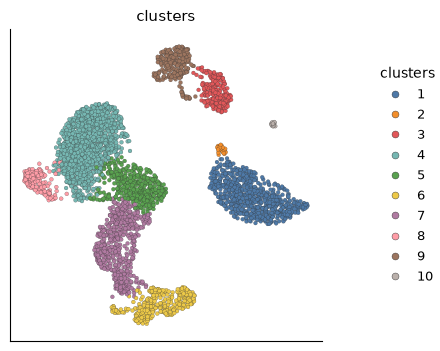

In [2]:
ds.plots.embedding(run=run, color_by="clusters")

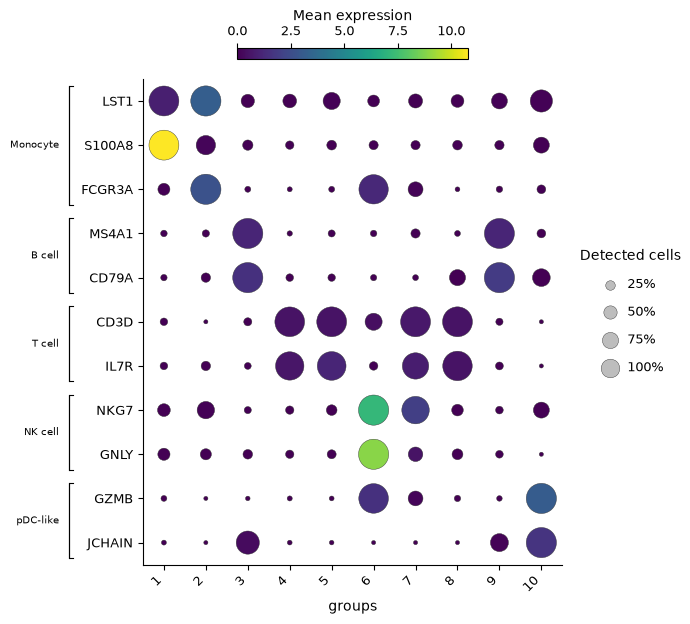

In [3]:
marker_panel = {
    "Monocyte": ["LST1", "S100A8", "FCGR3A"],
    "B cell": ["MS4A1", "CD79A"],
    "T cell": ["CD3D", "IL7R"],
    "NK cell": ["NKG7", "GNLY"],
    "pDC-like": ["GZMB", "JCHAIN"],
}
ds.plots.dotplot(features=marker_panel, groups=run["clusters"])

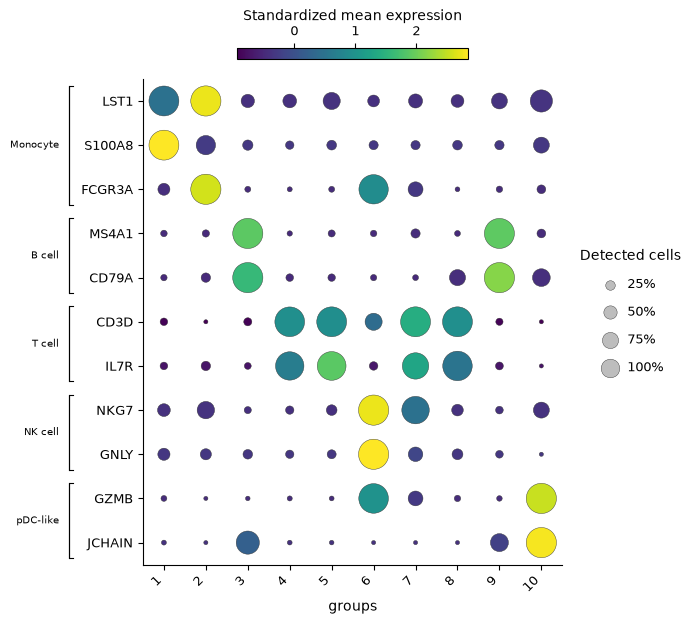

In [4]:
ds.plots.dotplot(features=marker_panel, groups=run['clusters'], standardize='feature')

In [5]:
cell_type_by_cluster = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "T cells",
    "8": "T cells",
    "9": "B cells",
    "10": "pDC-like cells",
}
cell_type_by_cluster

{'1': 'CD14 monocytes',
 '2': 'monocytes',
 '3': 'B cells',
 '4': 'T cells',
 '5': 'T cells',
 '6': 'NK cells',
 '7': 'T cells',
 '8': 'T cells',
 '9': 'B cells',
 '10': 'pDC-like cells'}

In [6]:
import numpy as np

analysis_cells = run.cells.fetch_all("I").astype(bool)
cluster_values = run.cells.fetch("clusters").astype(str)
cell_types = np.full(ds.cells.N, "Not analyzed", dtype=object)
cell_types[analysis_cells] = [cell_type_by_cluster[value] for value in cluster_values]
ds.cells.insert("pbmc_cell_type", cell_types, overwrite=True)
labels, counts = np.unique(cell_types[analysis_cells], return_counts=True)
{str(label): int(count) for label, count in zip(labels, counts, strict=True)}

{'B cells': 495,
 'CD14 monocytes': 716,
 'NK cells': 319,
 'T cells': 2378,
 'monocytes': 25,
 'pDC-like cells': 15}

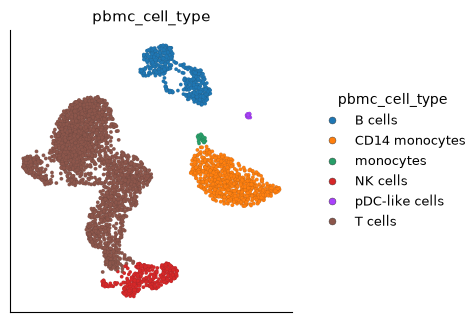

In [7]:
ds.plots.embedding(layout=run["umap"], color_by="pbmc_cell_type")